# Telco Customer Churn Analysis
**Goal:** Identify factors influencing customer retention and predict churn.
**Dataset:** [Kaggle Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


In [159]:
import pandas as pd
import numpy as npm
import matplotlib as plt
import seaborn as sns

In [160]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [161]:
df.shape

(7043, 21)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [163]:
# Check for rows that are seemingly not blank, but are just whitespace 
empty_or_whitespace_in_any_column = df.apply(lambda row: any(str(x).strip() == '' for x in row), axis=1)
print("\nRows with empty or whitespace-only strings in any column:")
print(df[empty_or_whitespace_in_any_column])


Rows with empty or whitespace-only strings in any column:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  

In [164]:
#From the result, we see the rows that have empty values
empty_rows = df.loc[[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]]
empty_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


#### The row of data that have empty values in the Total Charges column are that way because the customers just joined, and have not been billed at all. 
**Total charge = Tenure * Monthly charge**

Since this will not affect us, seing that it just 11 rows out of 7043 (~0.001), we will drop these columns

In [165]:
df = df.drop(df[empty_or_whitespace_in_any_column].index)


In [166]:
#cross check to see if the empty rows have been really cleared
#df.loc[6754] - it gives a keyError, so it has been dropped

#### Check for dupliacte rows

In [167]:
duplicates = df.duplicated()
duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7032, dtype: bool

#### Convert TotalCharges column from object to numeric

In [168]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### EDA
- Summary Stats
- Look at the target variable (Churn Distribution)
- Plot histograms for numerical columns and barplots for categorical columns
- Compare each feature with target variable
- Use correlation heatmap for numerical columns
- State out insights gotten
  

##### 1.Check summary stats

In [169]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### Check out the balance in churn distribution. 
#### We are checking so we can identify whether or not the yes or no's are balanced. This is important because it affects these: 
- If it is imblanaced, we cannot depend on accuracy as our metric for evaluation. This is because :
    - If we use accuracy, the model can predict more of either side, which looks okay, but in relaity is incorrect. 
    - We can use precision, because it will show us the ratio of predicted churn to the actual churn in reality. 
    - Recall: of customers who churned, how many you caught.
    - F1-score: balance between precision and recall.
    - ROC-AUC: shows how well the model separates the two classes overall.

In [170]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

#### INSIGHT: 
##### We can clearly see that we have 73% of non-churn to 27% of churn, which shows an imbalance in the classes. 



#### Plot histograms for numerical columns

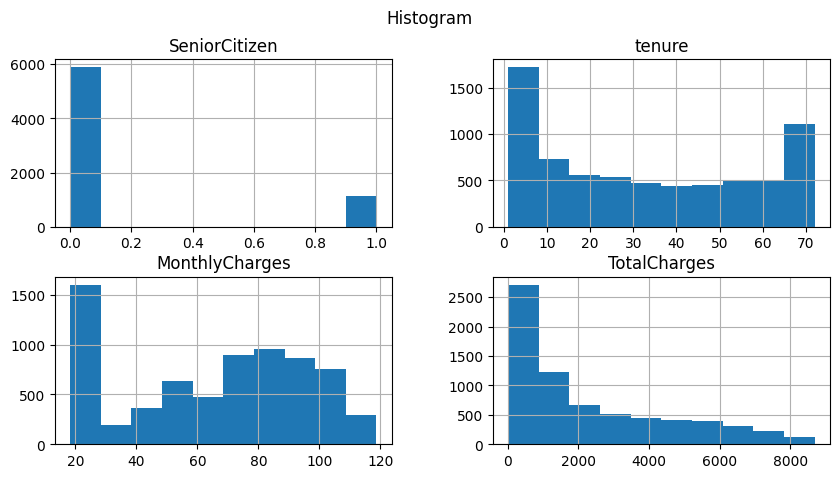

In [171]:
import matplotlib.pyplot as plt 
df.hist(figsize=(10, 5)) 
plt.suptitle('Histogram')
plt.show()

#### Plot Barplot for categorical values


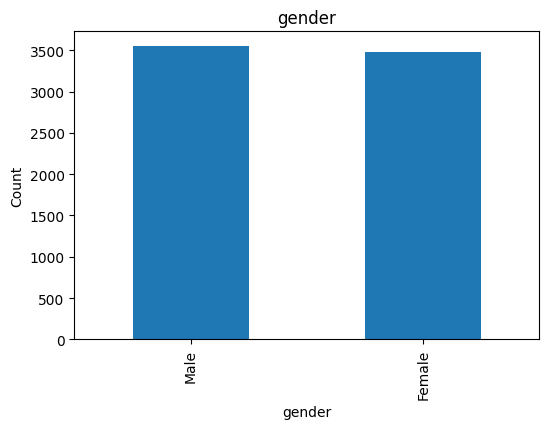

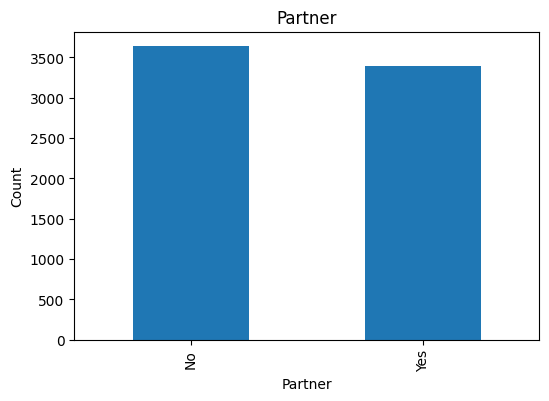

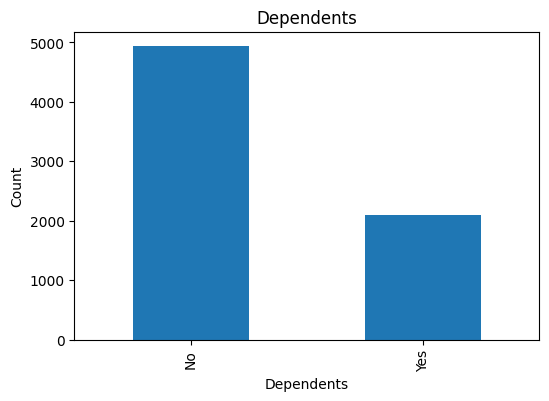

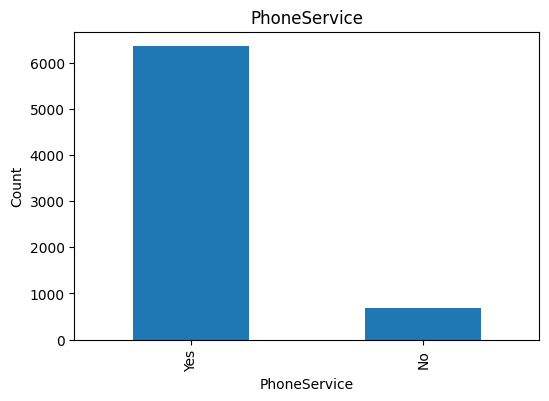

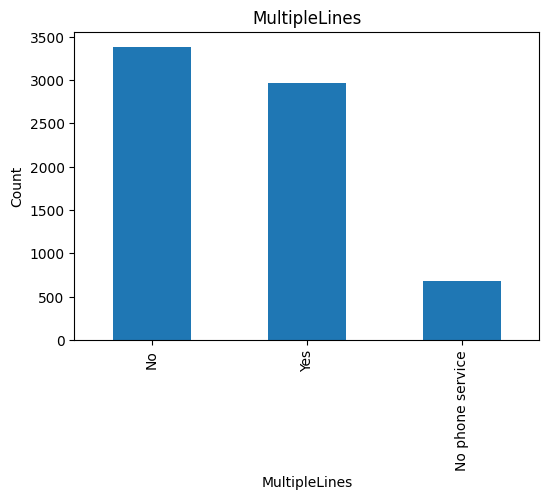

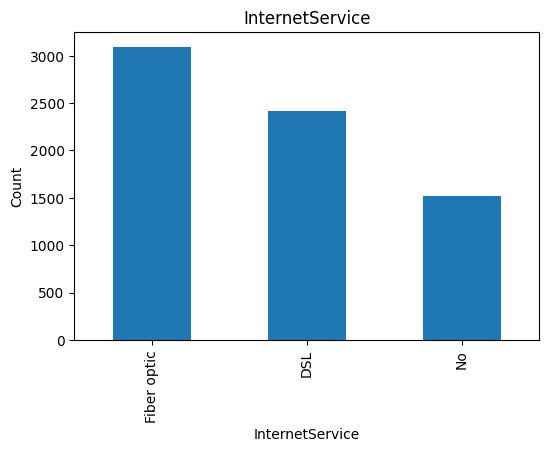

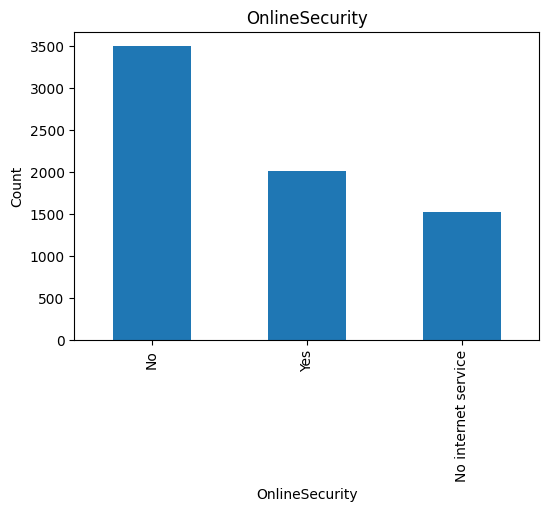

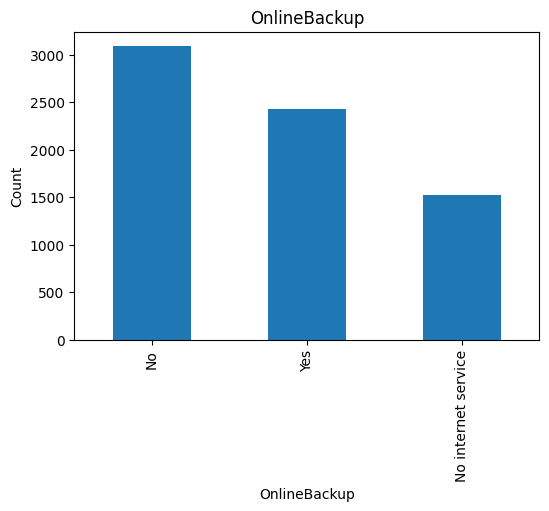

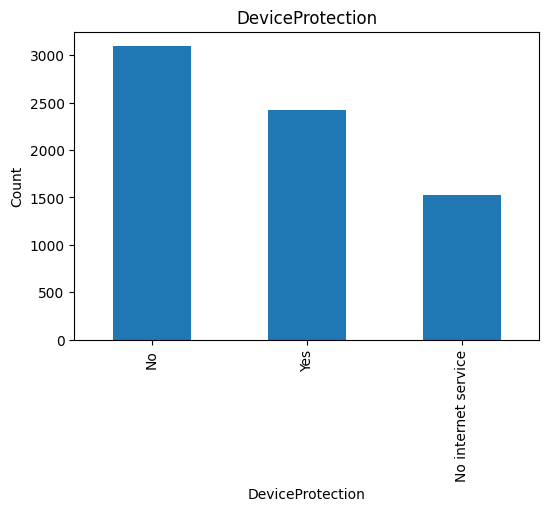

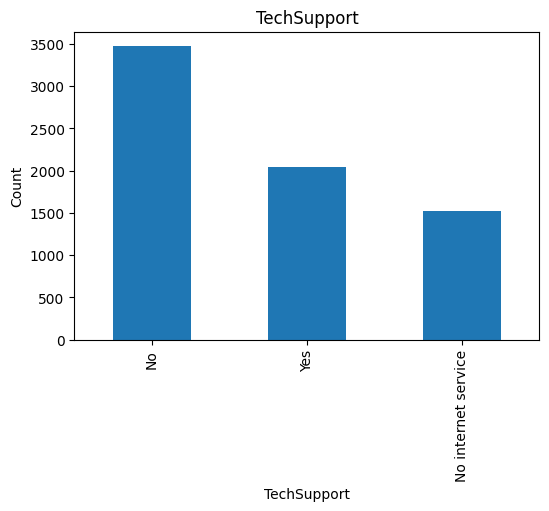

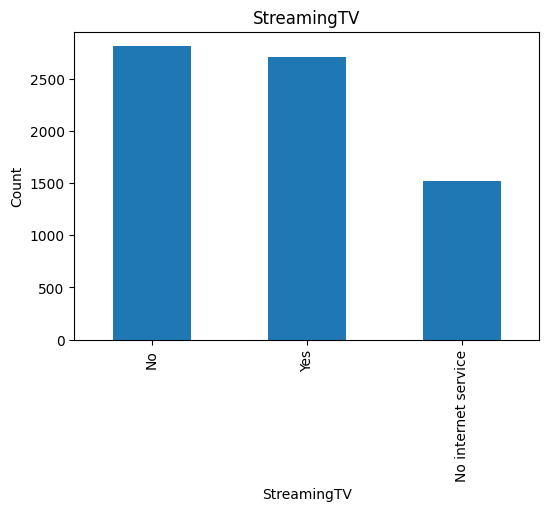

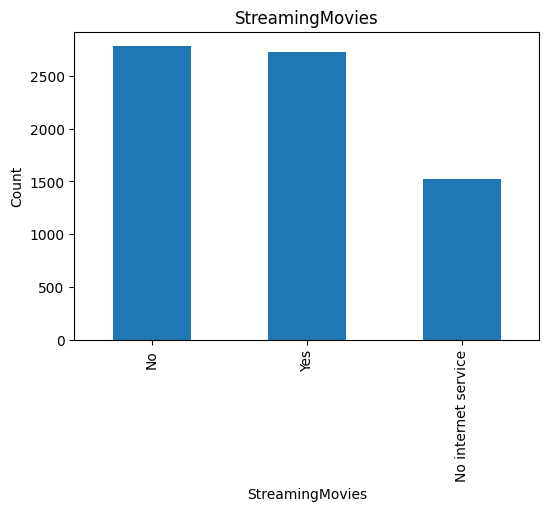

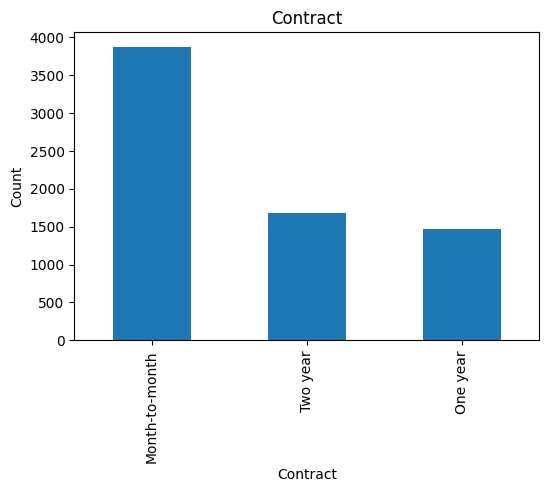

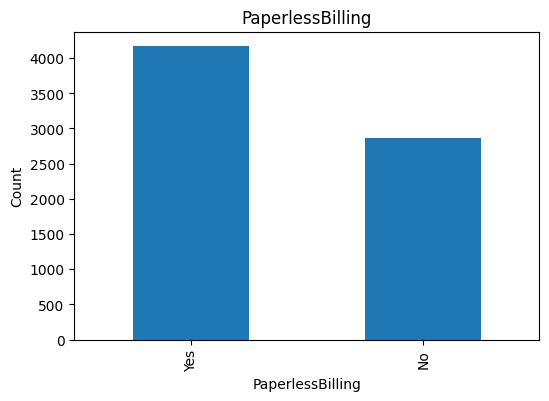

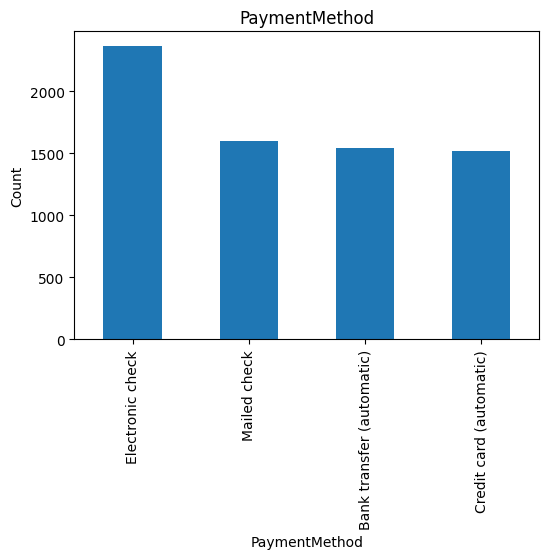

In [172]:
categorical_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_columns:
    df[col].value_counts().plot(kind='bar', figsize=(6,4), title=col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


#### Group categorical values by churn to see if the features influences churn or not

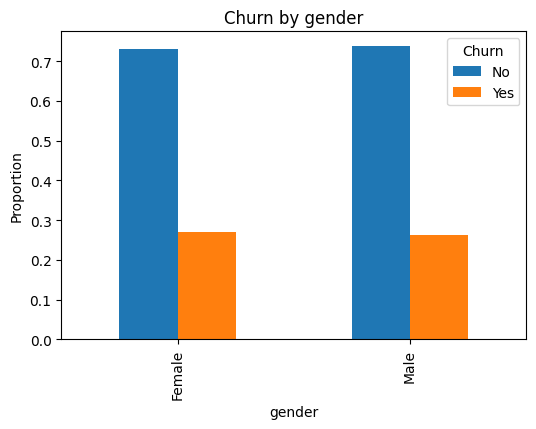

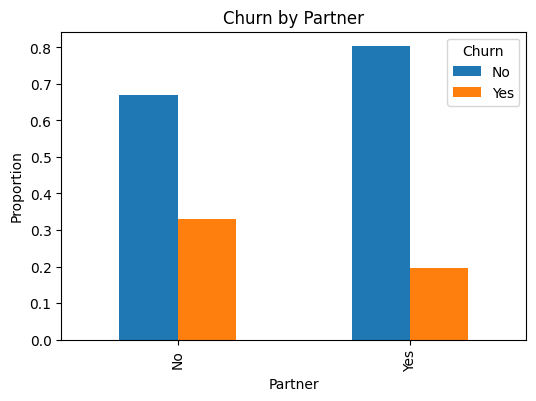

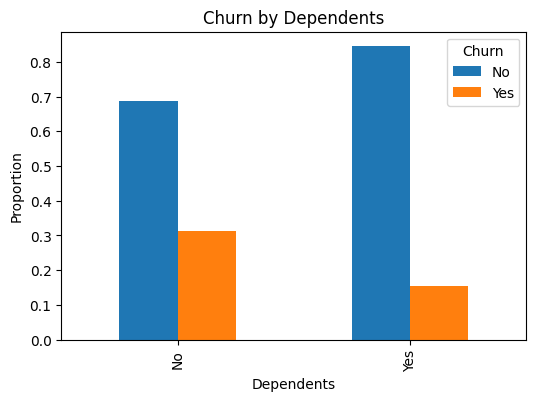

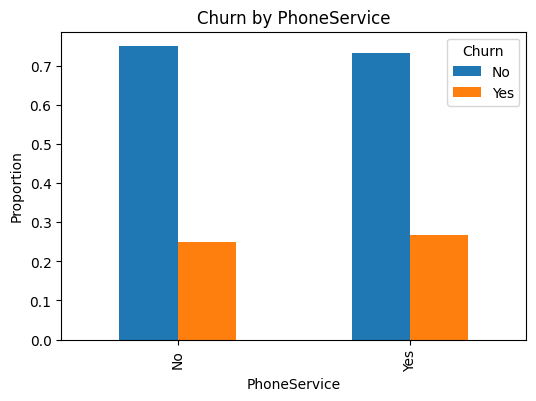

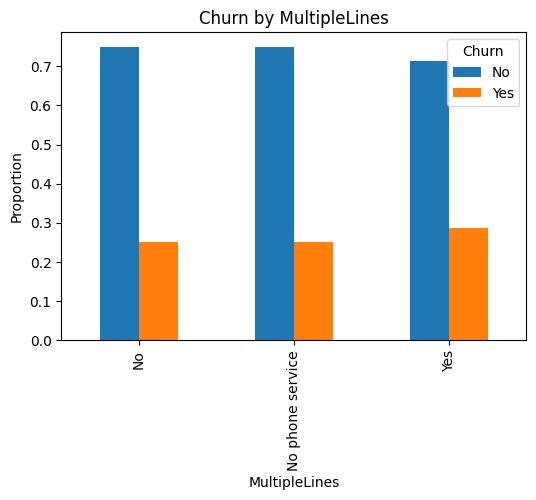

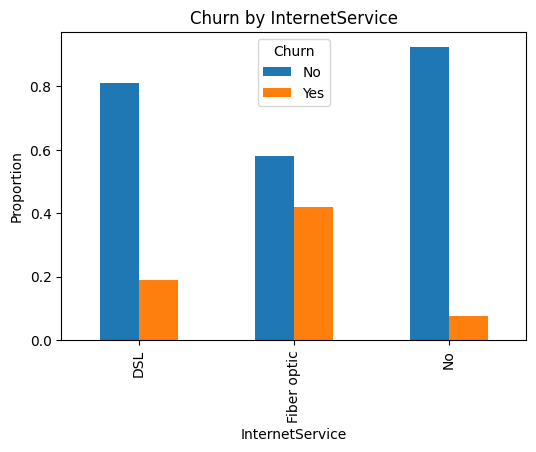

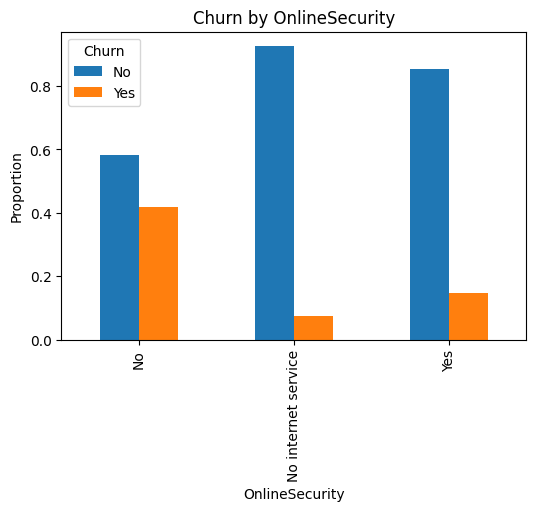

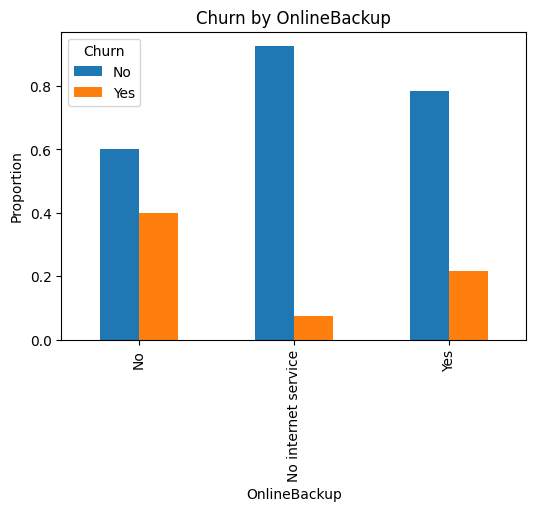

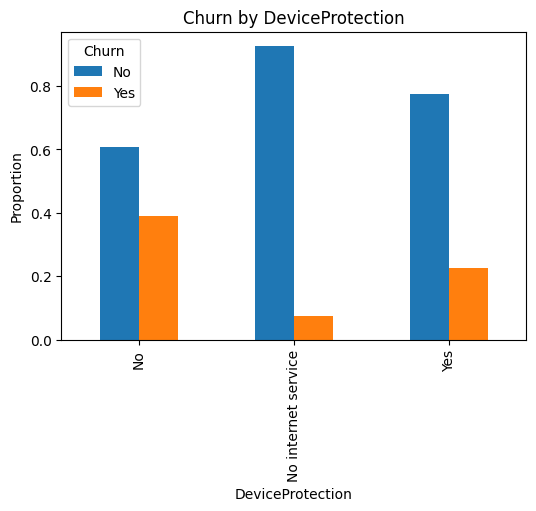

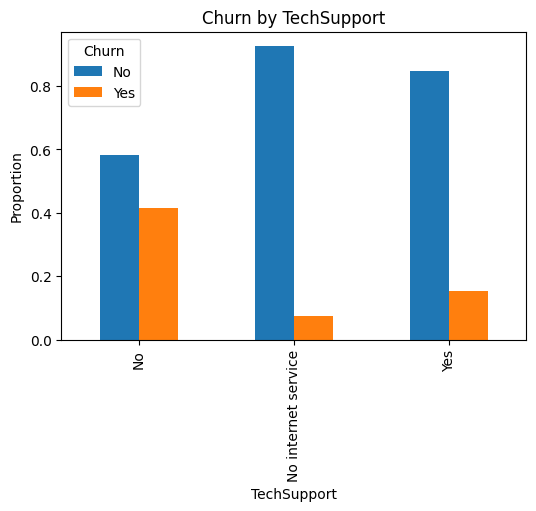

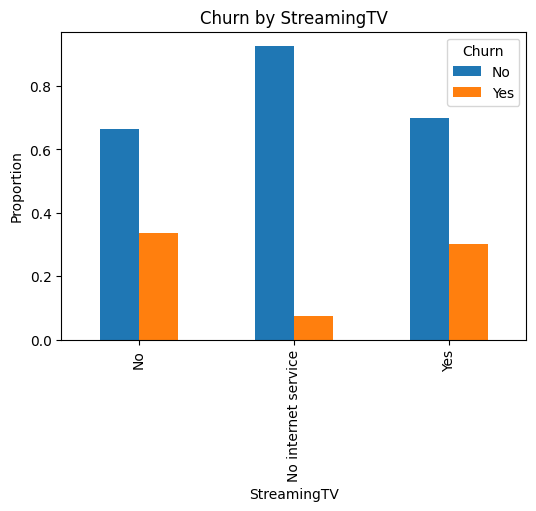

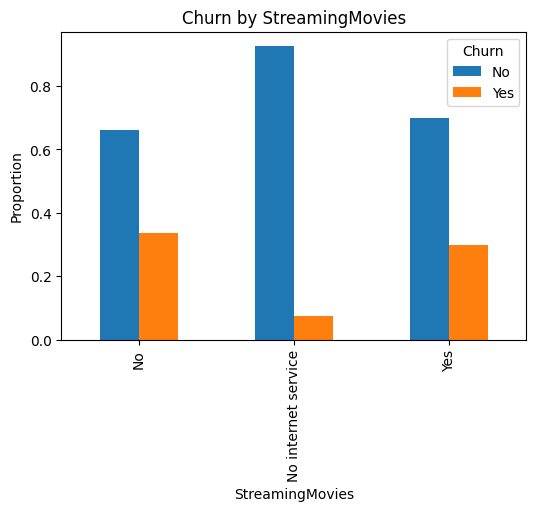

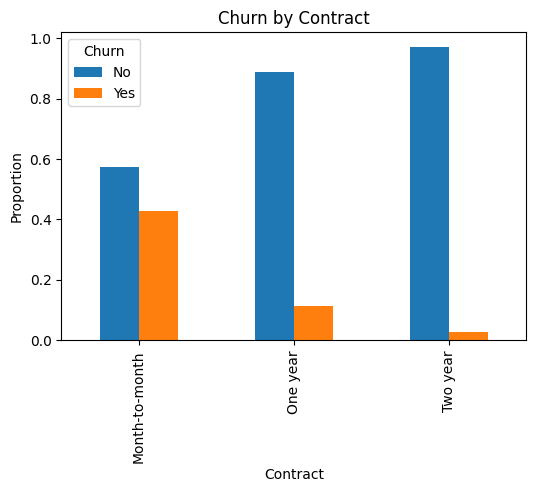

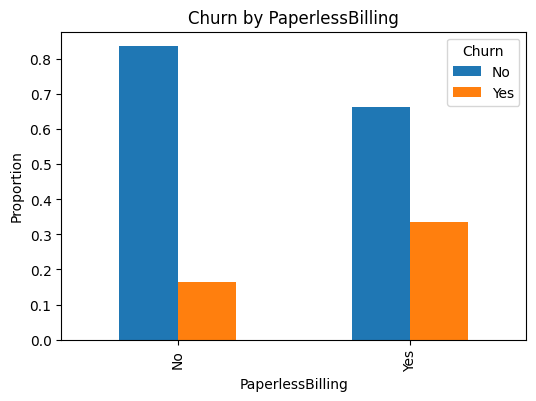

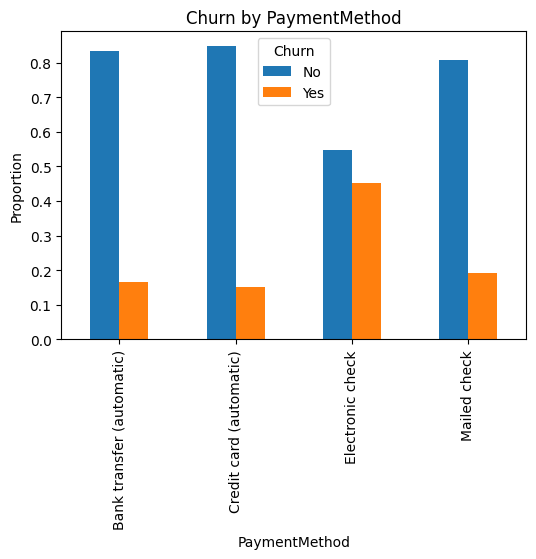

In [173]:
categorical_columns = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

for col in categorical_columns:
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    churn_rate.plot(kind='bar', figsize=(6,4), title=f'Churn by {col}')
    plt.ylabel('Proportion')
    plt.show()


#### Insights Summary

- Partner Status: Customers without partners exhibit higher churn rates, possibly due to lower household stability or financial commitment.

- Dependents: Customers without dependents churn more, suggesting that family responsibilities may correlate with higher retention.

- Phone Service: Customers with phone service churn more, indicating potential dissatisfaction with pricing or service quality.

- Internet Type:

   - Fibre optic customers have the highest churn rate.

   - DSL customers churn less.

- Customers without internet service churn the least.

- Online Security: Lack of online security strongly correlates with higher churn. Those without internet service show the lowest churn (by default).

- Contract Type:

   - Month-to-month contracts have the highest churn rate.

   - One-year contracts reduce churn.

   - Two-year contracts have the lowest churn rate.

- Billing Method: Customers using paperless billing churn more, possibly because digital-only interactions reduce engagement or because this group overlaps with short-term contract users.

In [174]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


numeric_features = df[['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn' ]]
correlation_matrix = numeric_features.corr()
print(correlation_matrix)



                SeniorCitizen  MonthlyCharges  TotalCharges    tenure  \
SeniorCitizen        1.000000        0.219874      0.102411  0.015683   
MonthlyCharges       0.219874        1.000000      0.651065  0.246862   
TotalCharges         0.102411        0.651065      1.000000  0.825880   
tenure               0.015683        0.246862      0.825880  1.000000   
Churn                0.150541        0.192858     -0.199484 -0.354049   

                   Churn  
SeniorCitizen   0.150541  
MonthlyCharges  0.192858  
TotalCharges   -0.199484  
tenure         -0.354049  
Churn           1.000000  


#### Interpretation:

- MonthlyCharges (0.193) → Weak positive correlation with churn. Higher monthly costs slightly increase likelihood of churn.

- SeniorCitizen (0.151) → Weak positive correlation. Older customers churn marginally more.

- TotalCharges (-0.199) → Weak negative correlation. Customers with higher lifetime spend (longer tenure) churn less.

- Tenure (-0.35) → Strongest negative correlation with churn. Longer-tenured customers are less likely to churn.

##### Conclusion: price sensitivity and short tenure are modest churn drivers. 

In [175]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### ENCODE CATEGORICAL VARIABLES

- Use LabelEncoding for binary options (e.g yes/no, male/female, partner/no-partner)
- Use OneHotEncoding for non-binary/non-ordinal options (e.g multipleLines, Payment method, etc )
    - Note that One-Hot Encoding creates new columns for each category
  

In [176]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [177]:
# 1.Gender
df['gender'] = le.fit_transform(df['gender'])

# 2. PhoneService
df['PhoneService'] = le.fit_transform(df['PhoneService'])

# 3. Partner
df['Partner'] = le.fit_transform(df['Partner'])

# 4. Dependents
df['Dependents'] = le.fit_transform(df['Dependents'])

# 5. PaperlessBilling
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])


In [178]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0


In [179]:
#USE ONE-HOT ENCODING FOR NON-BINARY/NON-ORDINAL VARIABLES

df = pd.get_dummies(df, columns=[
    'InternetService', 
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies', 
    'Contract', 
    'PaymentMethod',
    'MultipleLines'
], drop_first=True, dtype=int)


df.head(5)

#### Scale Numeric Data using Standard Scaler

In [181]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])



#### Drop unnecessary columns (e.g customerID)

In [190]:
#df = df.drop(columns=['customerID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   float64
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetS

### MODEL DEVELOPMENT


### We are trying three models: LogisticRegression, Random Forest and finally XGBoost and selecting the best. 


In [186]:
from sklearn.model_selection import train_test_split

In [192]:
features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
 'tenure', 'PhoneService', 'PaperlessBilling',
 'MonthlyCharges', 'TotalCharges',
 'InternetService_Fiber optic', 'InternetService_No',
 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service', 'OnlineBackup_Yes',
 'DeviceProtection_No internet service', 'DeviceProtection_Yes',
 'TechSupport_No internet service', 'TechSupport_Yes',
 'StreamingTV_No internet service', 'StreamingTV_Yes',
 'StreamingMovies_No internet service', 'StreamingMovies_Yes',
 'Contract_One year', 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
 'MultipleLines_No phone service', 'MultipleLines_Yes']

X = df[features]
y = df['Churn']

In [193]:
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Logistic Regression

In [196]:
from sklearn.linear_model import LogisticRegression

In [234]:
logistic_model = LogisticRegression(max_iter=1000, class_weight='balanced') 
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [235]:
log_predictions = logistic_model.predict(X_test)
print(log_predictions)
probabilities = logistic_model.predict_proba(X_test) # Get class probabilities
print(probabilities)
print("Done")

[0 0 1 ... 0 1 0]
[[0.98394526 0.01605474]
 [0.72034086 0.27965914]
 [0.14762314 0.85237686]
 ...
 [0.98218911 0.01781089]
 [0.46831443 0.53168557]
 [0.59121485 0.40878515]]
Done


#### Random Forest

In [203]:
from sklearn.ensemble import RandomForestClassifier 

In [242]:
randomf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
randomf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [243]:
random_predictions = randomf_model.predict(X_test)
print(random_predictions)
probabilities = randomf_model.predict_proba(X_test) # Get class probabilities
print(probabilities)
print("Done")

[0 0 1 ... 0 0 0]
[[1.   0.  ]
 [0.93 0.07]
 [0.45 0.55]
 ...
 [1.   0.  ]
 [0.74 0.26]
 [0.69 0.31]]
Done


#### XGBOOST

In [209]:
!pip install xgboost


import xgboost as xgb

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 1.5 MB/s eta 0:00:47
    --------------------------------------- 1.0/72.0 MB 1.6 MB/s eta 0:00:46
    --------------------------------------- 1.0/72.0 MB 1.6 MB/s eta 0:00:46
    --------------------------------------- 1.0/72.0 MB 1.6 MB/s eta 0:00:46
    --------------------------------------- 1.6/72.0 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 1.8/72.0 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 2.1/72.0 MB 1.2 MB/s eta 0:01:01
   - -------------------------------------- 2.4/72.0 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 2.9/72.0 MB 1.3 MB/s eta 0:00:53
   - ----------------------

In [249]:
# Calculate scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

XG_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight=scale_pos_weight, use_label_encoder=False, random_state=42 )

XG_model.fit(X_train, y_train)


C:\Users\user\miniconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:32:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [250]:
xg_predictions = XG_model.predict(X_test)
print(xg_predictions)
probabilities = XG_model.predict_proba(X_test) # Get class probabilities
print(probabilities)
print("Done")

[0 0 1 ... 0 0 0]
[[0.99762    0.00238001]
 [0.91601515 0.08398485]
 [0.31378108 0.6862189 ]
 ...
 [0.99799997 0.00200002]
 [0.68668103 0.31331894]
 [0.73259467 0.26740533]]
Done


#### Model Evaluation
- Recall (priority) → proportion of actual churners correctly identified.

- F1-score → balances recall and precision, good for overall performance.

- ROC-AUC → shows model’s ability to separate churners vs non-churners across thresholds.

##### For Logistic Regression

In [239]:
from sklearn.metrics import recall_score, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [241]:
from sklearn.metrics import classification_report

# Get predicted probabilities for churn
log_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

threshold = 0.35

# Convert probabilities to class predictions based on threshold
log_predictions_thresh = (log_pred_proba >= threshold).astype(int)

# Generate classification report using the new predictions
print(classification_report(y_test, log_predictions_thresh))


              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1549
           1       0.44      0.90      0.59       561

    accuracy                           0.67      2110
   macro avg       0.69      0.74      0.65      2110
weighted avg       0.81      0.67      0.68      2110



##### For Random Forest

In [248]:
# Get predicted probabilities for churn (class 1)
randf_pred_proba = randomf_model.predict_proba(X_test)[:, 1]

# Set a custom threshold of 0.35
threshold = 0.30
randf_predictions_thresh = (randf_pred_proba >= threshold).astype(int)

# Classification report with threshold
print(classification_report(y_test, randf_predictions_thresh))

# ROC-AUC Score (remains the same)
auc_score = roc_auc_score(y_test, randf_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")


              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1549
           1       0.52      0.72      0.60       561

    accuracy                           0.75      2110
   macro avg       0.70      0.74      0.71      2110
weighted avg       0.79      0.75      0.76      2110

ROC-AUC Score: 0.8161


##### For XGBoost

In [260]:

XG_pred_proba = XG_model.predict_proba(X_test)[:, 1]

best_thresh = 0.30
XG_predictions_final = (XG_pred_proba >= best_thresh).astype(int)
print(classification_report(y_test, XG_predictions_final))

auc_score = roc_auc_score(y_test, XG_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")


              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1549
           1       0.47      0.77      0.58       561

    accuracy                           0.71      2110
   macro avg       0.68      0.73      0.68      2110
weighted avg       0.78      0.71      0.72      2110

ROC-AUC Score: 0.8113


#### Insight
Logistic regression is best model with 90% recall

#### To get most important features so businesses can know what drives churn

In [261]:

# Get feature names
feature_names = X_train.columns

# Get coefficients
coefficients = logistic_model.coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value
feature_importance['AbsCoeff'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='AbsCoeff', ascending=False)

feature_importance[['Feature', 'Coefficient']]


,Feature,Coefficient
24,Contract_Two year,-1.469813
4,tenure,-1.381586
9,InternetService_Fiber optic,1.064342
23,Contract_One year,-0.846238
8,TotalCharges,0.684256
7,MonthlyCharges,-0.357274
20,StreamingTV_Yes,0.345760
22,StreamingMovies_Yes,0.339326
12,OnlineSecurity_Yes,-0.336154
5,PhoneService,-0.303611


### Top Features Influencing Churn

- **Contract type:** 2-year contracts greatly reduce churn risk; 1-year contracts also reduce churn but less strongly.  
- **Tenure:** Longer-tenured customers are less likely to churn.  
- **Internet service:** Customers with Fiber optic service are more likely to churn than those with other internet types.  
- **Charges:** TotalCharges and MonthlyCharges influence churn, with higher total charges slightly increasing churn.  
- **Services:** Streaming TV/Movies slightly increase churn likelihood, while Online Security and Phone Service reduce churn risk.


# Conclusion

In this project, we built a **Customer Churn Prediction Model** using three machine learning algorithms: **Logistic Regression, Random Forest, and XGBoost**. The goal was to identify customers at risk of leaving the service based on their demographic and usage patterns.

## Model Comparison

| Model                  | Best Threshold | Precision (Churn) | Recall (Churn) | F1-Score (Churn) | ROC-AUC |
|------------------------|----------------|-----------------|----------------|-----------------|---------|
| Logistic Regression     | 0.35           | 0.44            | 0.90           | 0.59            | 0.8384  |
| Random Forest           | 0.30           | 0.52            | 0.72           | 0.60            | 0.8161  |
| XGBoost                 | 0.30           | 0.47            | 0.77           | 0.58            | 0.8113  |

**Observation:** Logistic Regression achieved the highest recall for churners (90%) and the best ROC-AUC, making it the most effective at identifying at-risk customers. Random Forest and XGBoost are competitive but slightly less effective on this dataset.

## Key Insights

- Customer churn is **imbalanced** (~25% churn rate), making threshold tuning critical for identifying at-risk customers.  
- **Threshold adjustment** improved recall for churners without dramatically reducing precision.  
- **Top drivers of churn** include:
  - **Contract type:** 2-year contracts strongly reduce churn risk; 1-year contracts also help.  
  - **Tenure:** Longer-tenured customers are less likely to churn.  
  - **Internet service:** Customers with Fiber optic service are more likely to churn.  
  - **Charges:** Higher TotalCharges slightly increase churn likelihood.  
  - **Services:** Streaming TV/Movies slightly increase churn likelihood, while Online Security and Phone Service reduce risk.

## Recommendation

The **Logistic Regression model with a threshold of 0.35** is recommended for deployment in this project. It balances recall and precision effectively, ensuring that the majority of at-risk customers are correctly identified while maintaining overall model reliability.


